In [ ]:
import sys

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import math

print("python:", sys.version.split()[0])
print("pandas:", pd.__version__)
print("numpy:", np.__version__)
print("seaborn:", sns.__version__)
print("matplotlib:", plt.matplotlib.__version__)

In [2]:
df =pd.read_csv('clean_dataset.csv')
display(df.head())

,country,year,region,economic_tier,happiness_rank,global_hunger_rank,human_development_rank,gdp_per_capita_rank,life_expectancy_rank,corruption_perception_rank,democracy_rank,gini_rank,press_freedom_rank,global_peace_rank,environmental_performance_rank
0,Afghanistan,2000,Asia,low,195,208,187,212,186,185,215,183,214,216,212
1,Afghanistan,2001,Asia,low,198,207,188,215,186,185,215,180,214,217,214
2,Afghanistan,2002,Asia,low,196,208,192,213,185,185,215,174,214,217,213
3,Afghanistan,2003,Asia,low,196,207,195,214,183,185,215,173,214,217,214
4,Afghanistan,2004,Asia,low,194,210,197,214,183,185,216,172,214,217,212


In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
year,5859.0,2013.000000,7.789546,2000.0,2006.0,2013.0,2020.0,2026.0
happiness_rank,5859.0,109.000000,62.647186,1.0,55.0,109.0,163.0,217.0
global_hunger_rank,5859.0,96.936849,75.533151,1.0,1.0,109.0,163.0,217.0
human_development_rank,5859.0,108.586790,62.031375,1.0,55.0,109.0,163.0,217.0
gdp_per_capita_rank,5859.0,108.971155,62.689388,1.0,55.0,109.0,163.0,217.0
life_expectancy_rank,5859.0,108.995904,62.649583,1.0,55.0,109.0,163.0,217.0
corruption_perception_rank,5859.0,109.000000,62.647186,1.0,55.0,109.0,163.0,217.0
democracy_rank,5859.0,109.000000,62.647186,1.0,55.0,109.0,163.0,217.0
gini_rank,5859.0,108.951528,62.672195,1.0,55.0,109.0,163.0,217.0
press_freedom_rank,5859.0,109.000000,62.647186,1.0,55.0,109.0,163.0,217.0


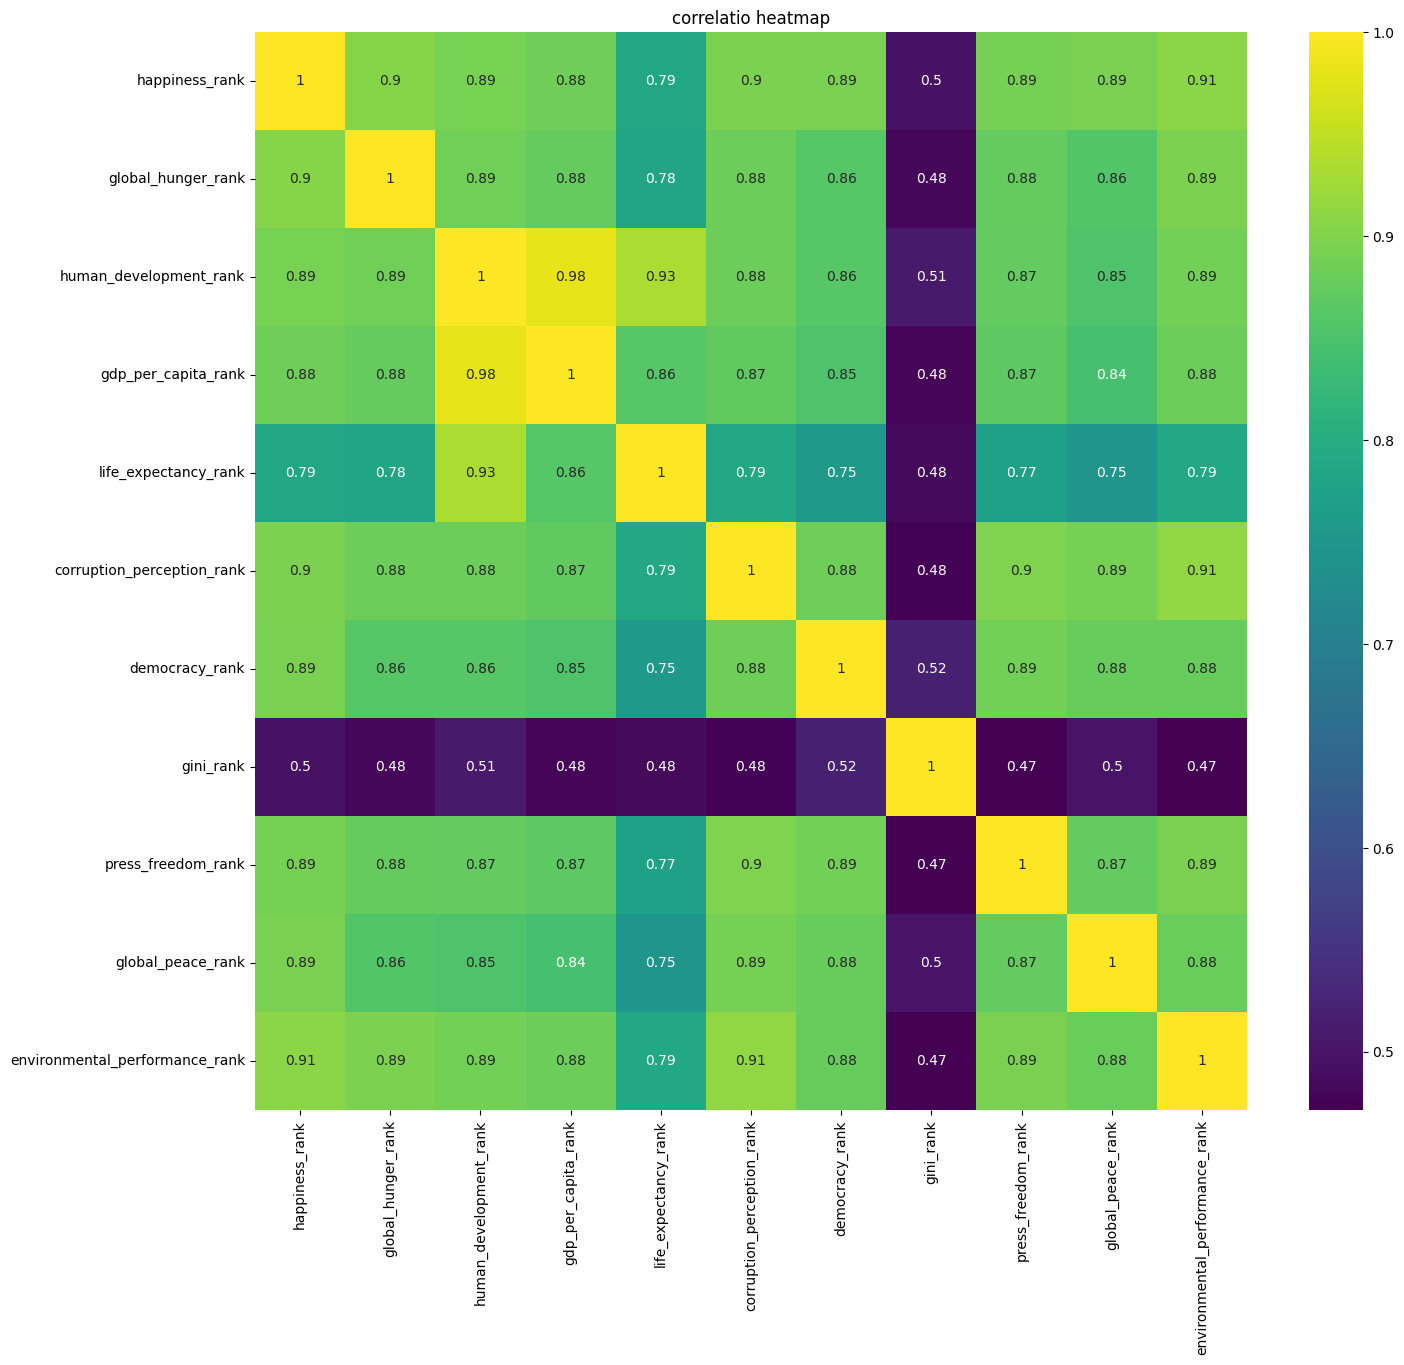

In [10]:
drop_col = df.drop(columns=['year'])
numeric_cols = drop_col.select_dtypes(include=['int64','float32','int32','float64'])
plt.figure(figsize=(16,14))
sns.heatmap(numeric_cols.corr() , annot=True ,cmap="viridis" )
plt.title("correlatio heatmap")
plt.show()

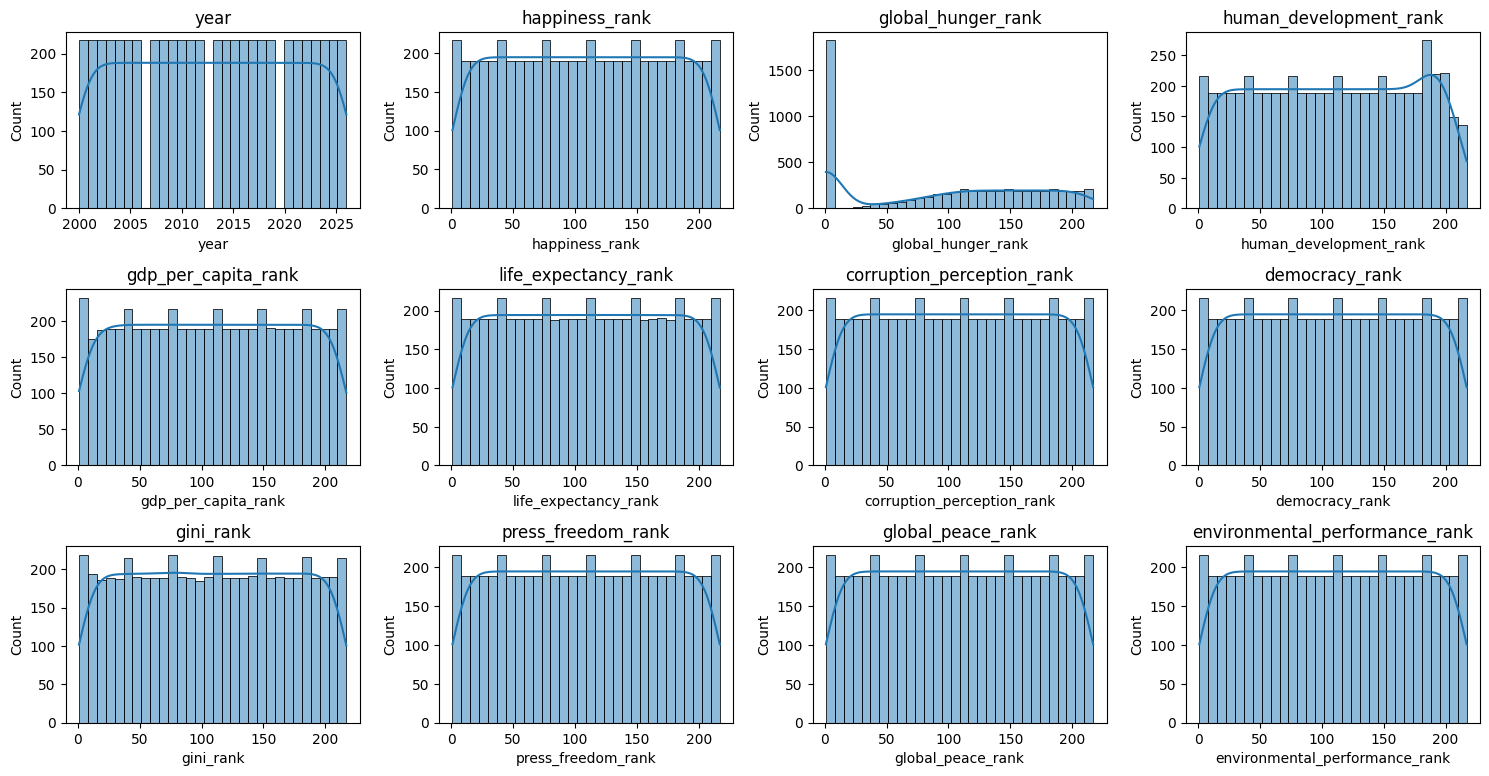

In [11]:
# distribution plot for numerical columns
numerical_cols = df.select_dtypes(include=["float64", "int64"]).columns
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(4, 4, i + 1) # adjust the number of rows and columns as needed
    sns.histplot(df[col], kde=True , bins = 30)
    plt.title(col)
plt.tight_layout()
plt.show()

1 . top 10 country base on happiness rank for each year

,year,country,avg_happiness_rank
0,2000,Norway,1.0
1,2000,San Marino,2.0
2,2000,Slovak Republic,3.0
3,2000,Malta,4.0
4,2000,Australia,5.0
...,...,...,...
265,2026,Panama,6.0
266,2026,Sint Maarten (Dutch part),7.0
267,2026,"Bahamas, The",8.0
268,2026,Luxembourg,9.0


top 10 Countries by Happiness Rank (Year-wise)


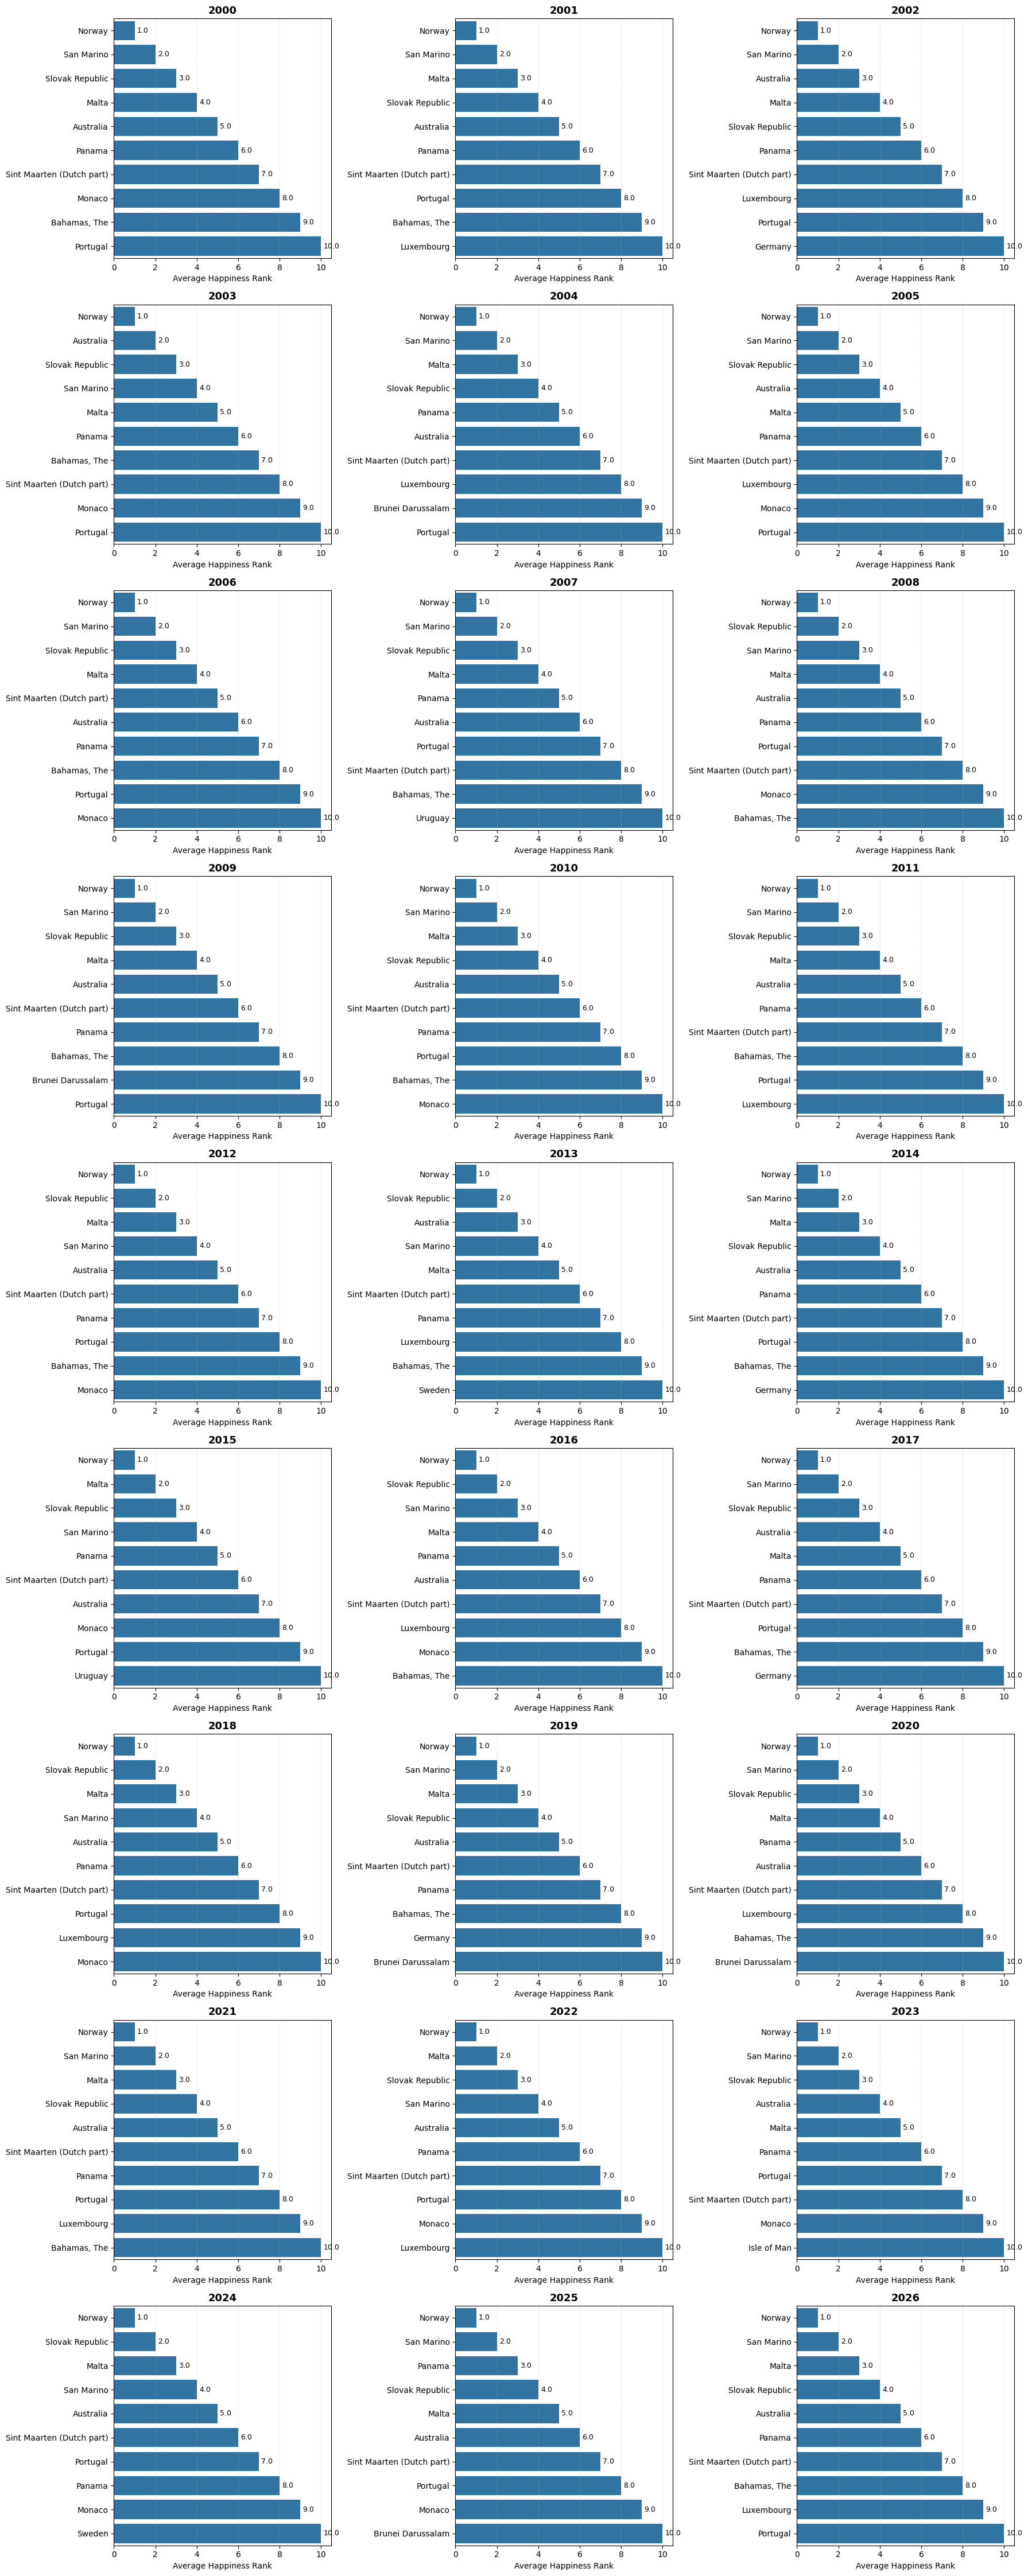

In [33]:
country_rank = (
    df.groupby(['year', 'country'])
      .agg(avg_happiness_rank=('happiness_rank', 'mean'))
      .round(2)
      .reset_index()
)

top10_country = (
    country_rank.sort_values(['year', 'avg_happiness_rank']).groupby('year', group_keys=False)
    .head(10).reset_index(drop=True)
)
display(top10_country)
print("top 10 Countries by Happiness Rank (Year-wise)")
years = sorted(top10_country['year'].unique())

n_cols = 3
n_rows = math.ceil(len(years) / n_cols)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(18, 5 * n_rows)
)

axes = axes.flatten()

for i, year in enumerate(years):

    temp = (
        top10_country[top10_country['year'] == year]
        .sort_values('avg_happiness_rank')
    )

    ax = axes[i]

    sns.barplot(
        data=temp,
        x='avg_happiness_rank',
        y='country',
        ax=ax
    )

    # Data Labels
    for container in ax.containers:
        ax.bar_label(
            container,
            fmt='%.1f',
            padding=3,
            fontsize=9
        )

    ax.set_title(f"{year}", fontsize=13, weight='bold')
    ax.set_xlabel("Average Happiness Rank")
    ax.set_ylabel("")
    ax.grid(axis='x', linestyle='--', alpha=0.3)

# Remove unused subplots
for j in range(len(years), len(axes)):
    fig.delaxes(axes[j])


plt.tight_layout()
plt.show()

2 . overall happiness rank distribution base on country

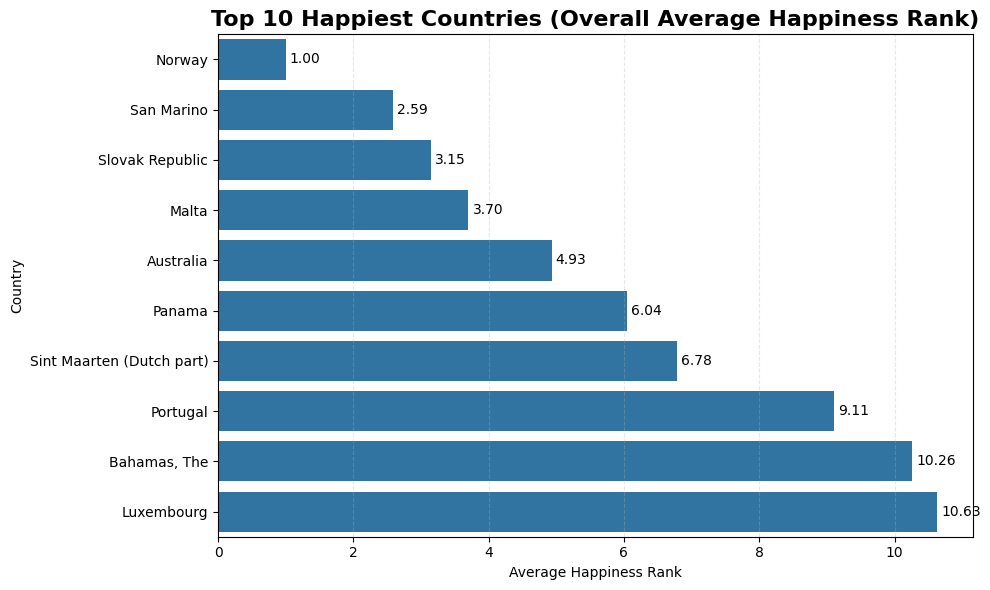

In [22]:
overall_happy = (
    df.groupby('country')
      .agg(avg_rank=('happiness_rank', 'mean'))
      .round(2)
      .sort_values(by='avg_rank', ascending=True)   # Lower rank = happier
      .head(10)
      .reset_index()
)

# display(overall_happy)

plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=overall_happy,
    x='avg_rank',
    y='country'
)

# Add data labels
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=3, fontsize=10)

plt.title("Top 10 Happiest Countries (Overall Average Happiness Rank)",
          fontsize=16, weight='bold')
plt.xlabel("Average Happiness Rank")
plt.ylabel("Country")
plt.grid(axis='x', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

3 . top 10 coutry base on globle hunger rank each and every year

top 10 country base on avg hunge rank for each year


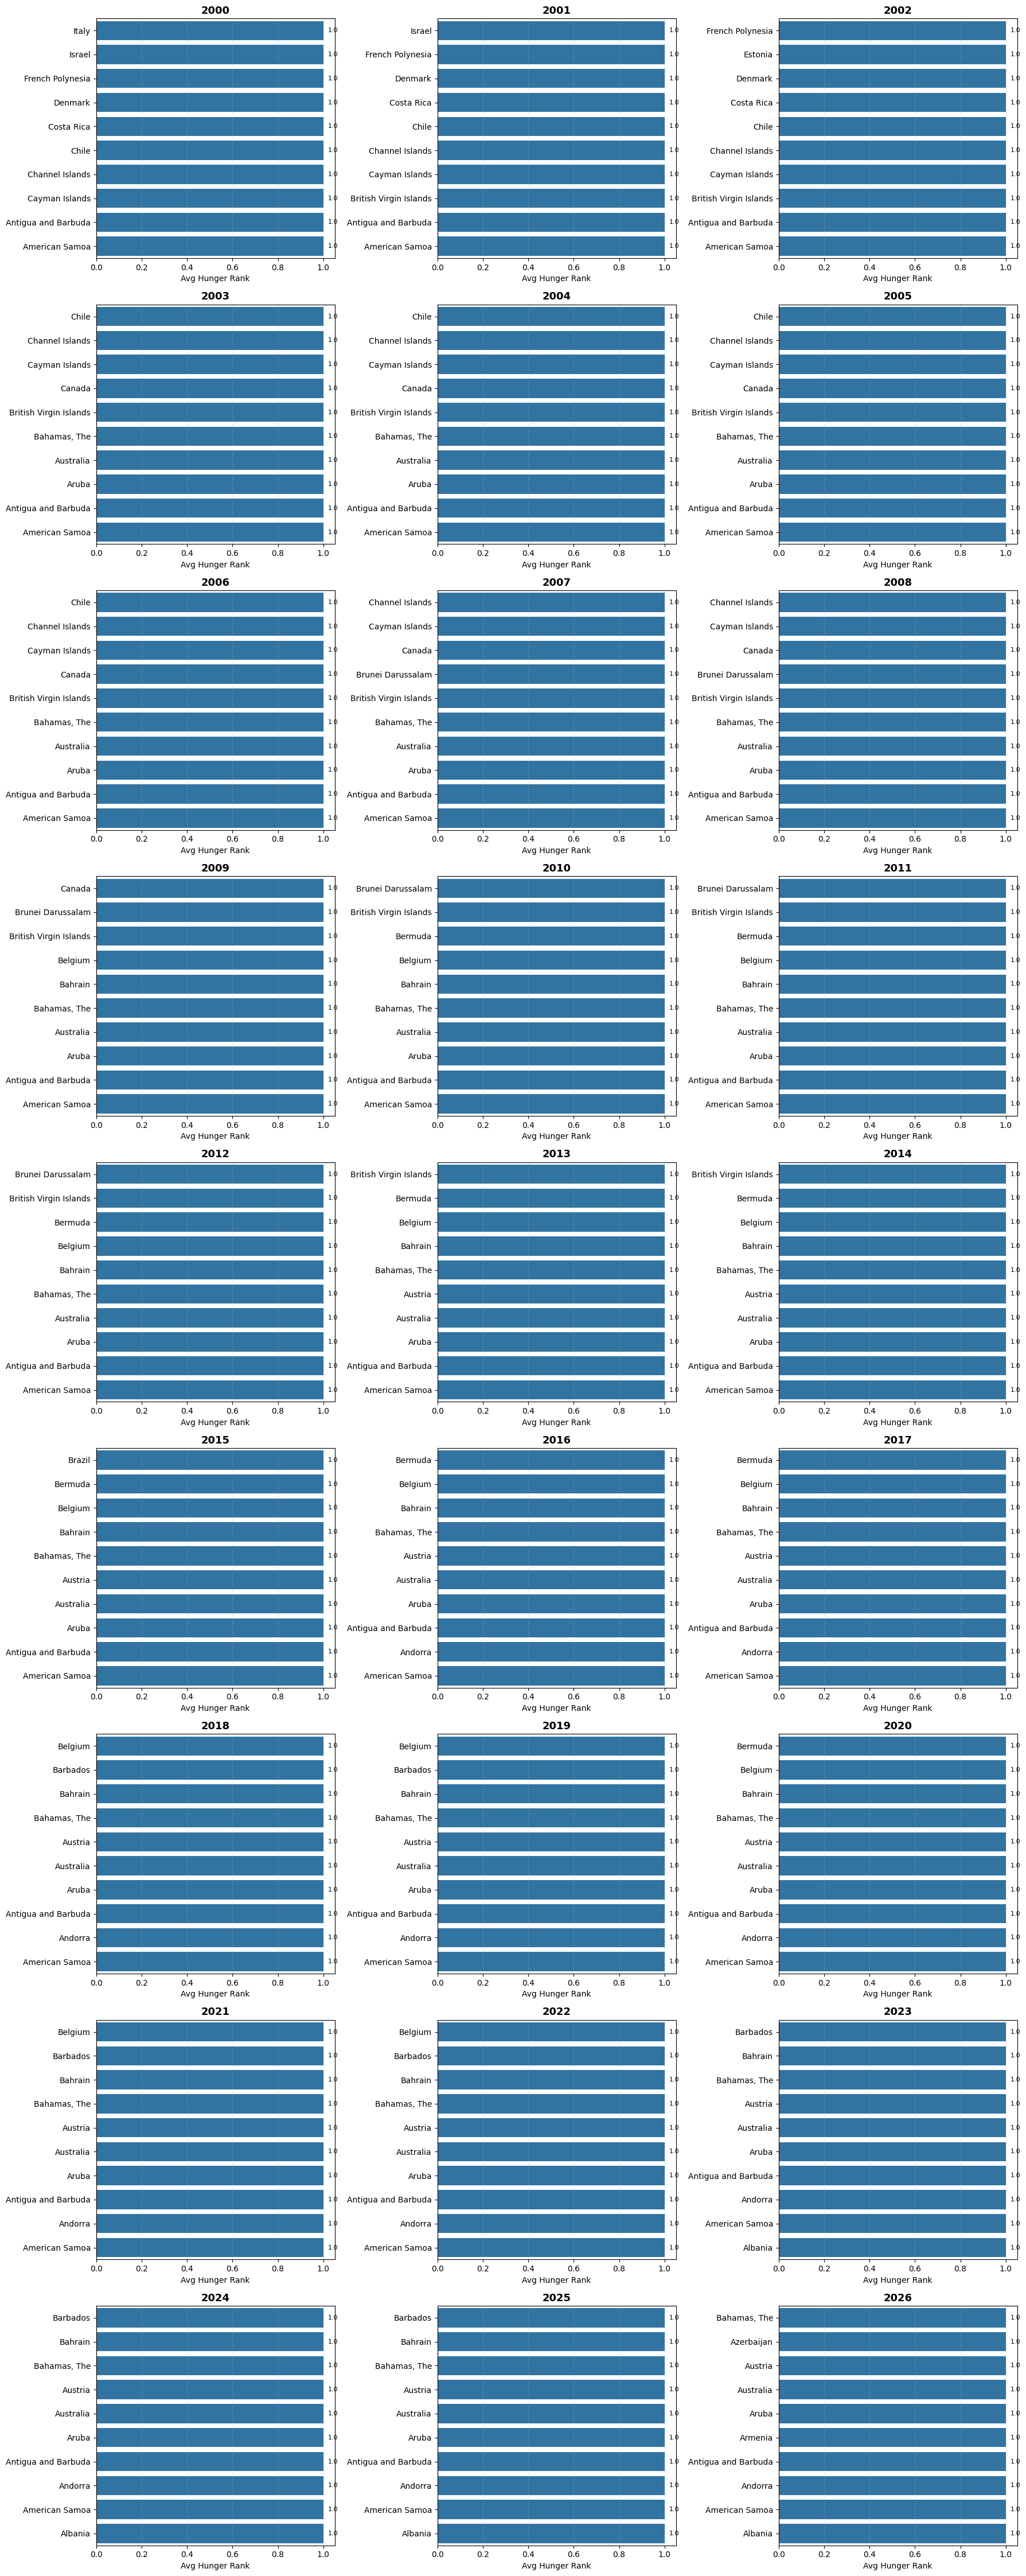

In [50]:
# Average Global Hunger Rank by Year and Country
mean_rank = (
    df.groupby(['year', 'country'])
      .agg(avg_hunger_rank=('global_hunger_rank', 'mean'))
      .round(2)
      .reset_index()
)

# Top 10 countries (lowest Global Hunger Rank) for each year
top10_per_year = (
    mean_rank
      .sort_values(['year', 'avg_hunger_rank'])
      .groupby('year', group_keys=False)
      .head(10)
      .reset_index(drop=True)
)

# display(top10_per_year)
print("top 10 country base on avg hunge rank for each year")

years = sorted(top10_per_year['year'].unique())

n_cols = 3
n_rows = math.ceil(len(years) / n_cols)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(18, 5 * n_rows)
)

# Convert axes to a flat array
axes = axes.flatten()

for i, year in enumerate(years):

    temp = (
        top10_per_year[top10_per_year['year'] == year]
        .sort_values('avg_hunger_rank', ascending=True)
    )

    ax = axes[i]

    sns.barplot(
        data=temp,
        x='avg_hunger_rank',
        y='country',
        ax=ax
    )

    # Data labels
    for container in ax.containers:
        ax.bar_label(
            container,
            fmt='%.1f',
            padding=6,
            fontsize=8
        )

    ax.set_title(f"{year}", fontsize=13, weight='bold')
    ax.set_xlabel("Avg Hunger Rank")
    ax.set_ylabel("")
    ax.grid(axis='x', linestyle='--', alpha=0.3)
    ax.invert_yaxis()   # Rank 1 at the top

# Hide any unused subplots
for j in range(len(years), len(axes)):
    fig.delaxes(axes[j])

# fig.suptitle(
#     "Top 10 Countries by Global Hunger Rank (Year-wise)",
#     fontsize=18,
#     weight='bold'
# )

plt.tight_layout()
plt.show()

4 . top 10 country base on human development rank

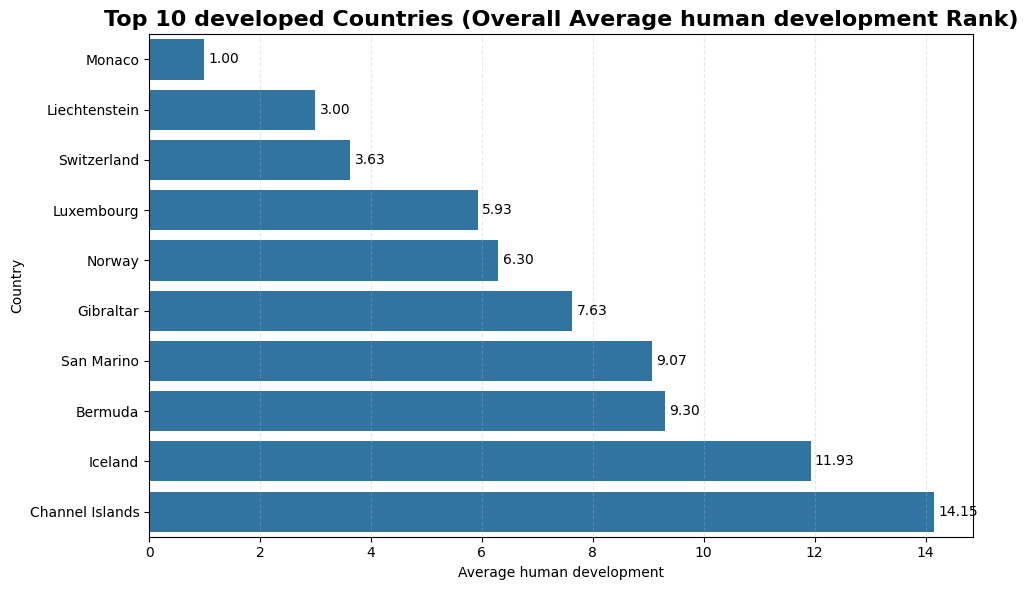

In [20]:
human_development = (
    df.groupby('country')
      .agg(avg_human_development_rank=('human_development_rank', 'mean'))
      .round(2)
      .sort_values(by='avg_human_development_rank', ascending=True)   # Lower rank = happier
      .head(10)
      .reset_index()
)
# display(human_development)

plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=human_development,
    x='avg_human_development_rank',
    y='country'
)

# Add data labels
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=3, fontsize=10)

plt.title("Top 10 developed Countries (Overall Average human development Rank)",
          fontsize=16, weight='bold')
plt.xlabel("Average human development")
plt.ylabel("Country")
plt.grid(axis='x', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()


5 . top 10 country base on GDP rank for each region 

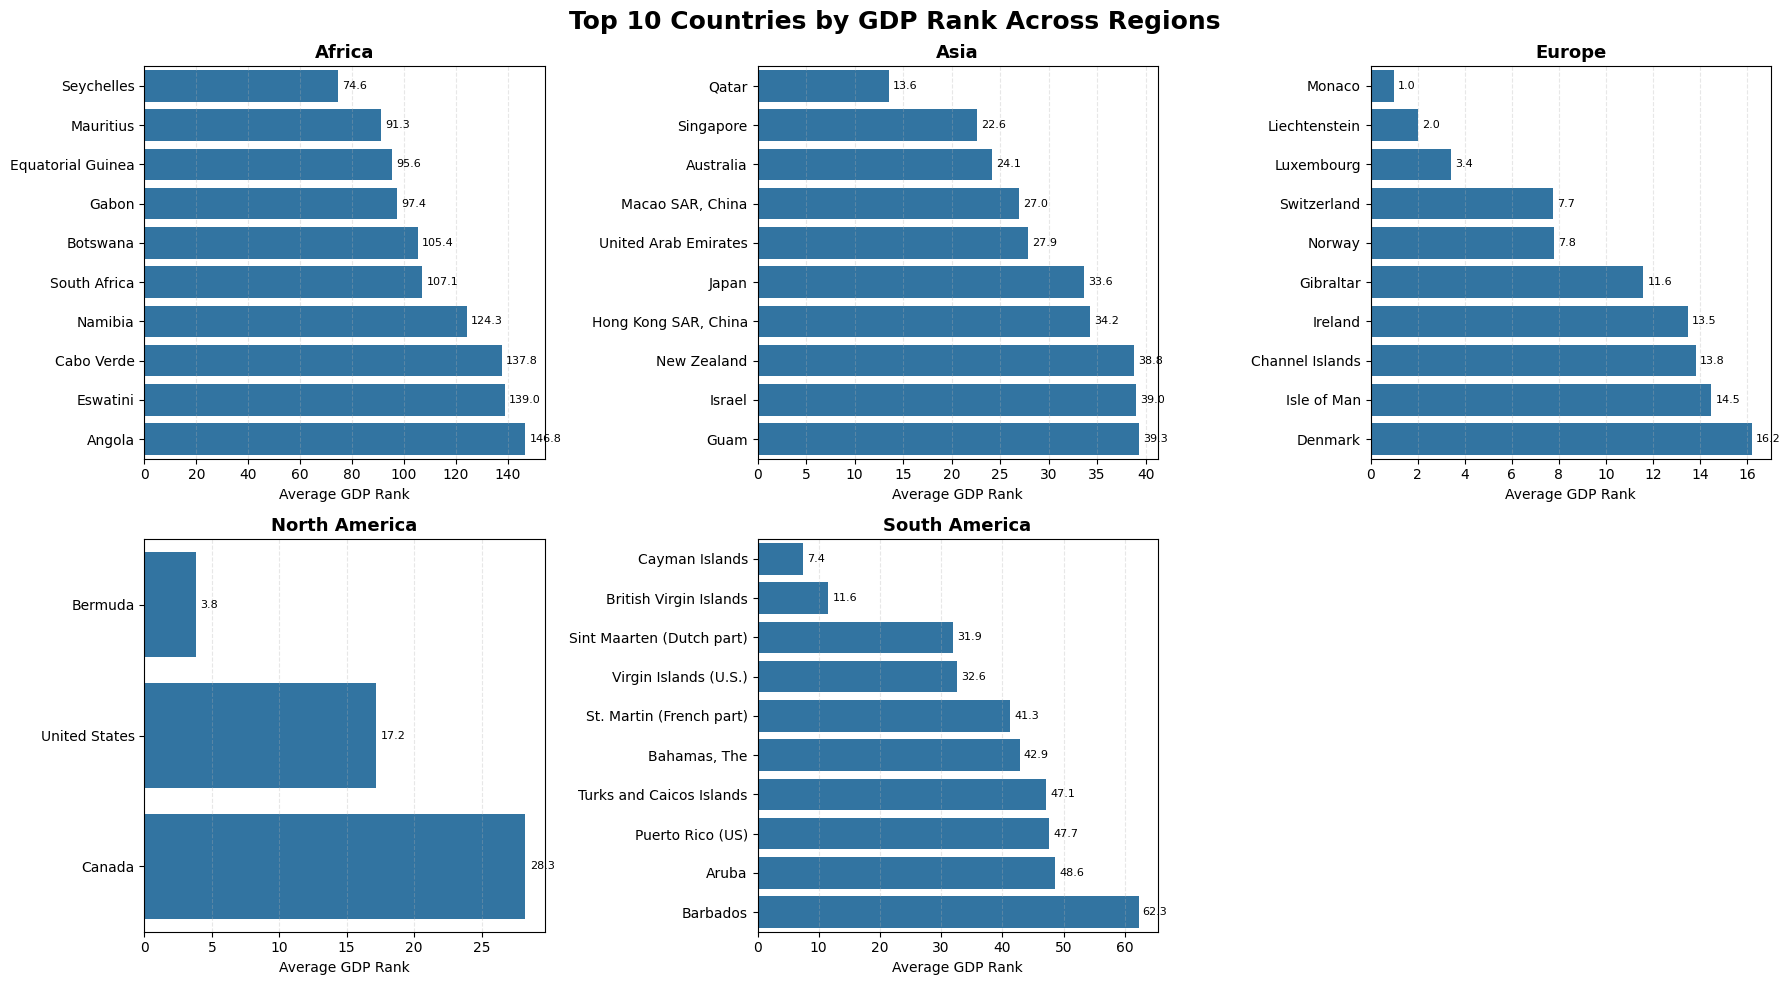

In [15]:
region_country = (df.groupby(['region' , 'country']).agg(
    avg_gdp_rnk = ('gdp_per_capita_rank' , 'mean')
).round(2).reset_index()
)


top10_per_region = (
    region_country
      .sort_values(['region', 'avg_gdp_rnk'])
      .groupby('region', group_keys=False)
      .head(10)
      .reset_index(drop=True)
)
# display(top10_per_region)

regions = sorted(top10_per_region['region'].unique())

n_cols = 3
n_rows = math.ceil(len(regions) / n_cols)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(18, 5 * n_rows)
)

axes = axes.flatten()

for i, region in enumerate(regions):

    temp = (
        top10_per_region[top10_per_region['region'] == region]
        .sort_values('avg_gdp_rnk', ascending=True)
    )

    ax = axes[i]

    sns.barplot(
        data=temp,
        x='avg_gdp_rnk',
        y='country',
        ax=ax
    )

    # Data Labels
    for container in ax.containers:
        ax.bar_label(
            container,
            fmt='%.1f',
            padding=3,
            fontsize=8
        )

    ax.set_title(region, fontsize=13, weight='bold')
    ax.set_xlabel("Average GDP Rank")
    ax.set_ylabel("")
    ax.grid(axis='x', linestyle='--', alpha=0.3)

    # Rank 1 at top
    # ax.invert_yaxis()

# Remove empty subplots
for j in range(len(regions), len(axes)):
    fig.delaxes(axes[j])

fig.suptitle(
    "Top 10 Countries by GDP Rank Across Regions",
    fontsize=18,
    weight='bold'
)

plt.tight_layout()
plt.show()

6 . top 20 country base on life Expectancy rank

,life_expetence
country,
Monaco,1.07
San Marino,3.63
"Hong Kong SAR, China",3.78
Japan,4.96
Andorra,5.56
Switzerland,7.04
"Macao SAR, China",8.56
Italy,11.22
Gibraltar,11.30


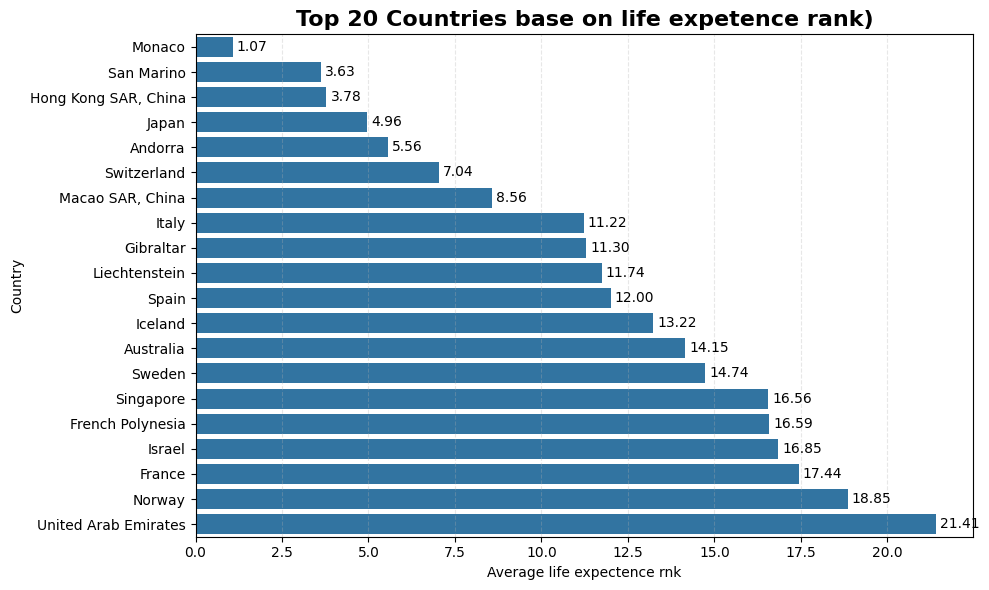

In [27]:
life_expetency = (df.groupby('country').agg(
    life_expetence = ('life_expectancy_rank' , 'mean')
).round(2).sort_values(by='life_expetence').head(20))
display(life_expetency)


plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=life_expetency,
    x='life_expetence',
    y='country'
)

# Add data labels
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=3, fontsize=10)

plt.title("Top 20 Countries base on life expetence rank)",
          fontsize=16, weight='bold')
plt.xlabel("Average life expectence rnk")
plt.ylabel("Country")
plt.grid(axis='x', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

7 . top 5 country base on corruption perception rank for each region

,region,country,avg_corruprion_rank
0,Africa,Seychelles,44.22
1,Africa,Mauritius,89.00
2,Africa,Gabon,91.33
3,Africa,Botswana,98.89
4,Africa,Cabo Verde,109.93
5,Asia,Israel,2.15
6,Asia,"Korea, Rep.",5.00
7,Asia,Northern Mariana Islands,17.11
8,Asia,Saudi Arabia,19.22
9,Asia,Guam,22.44


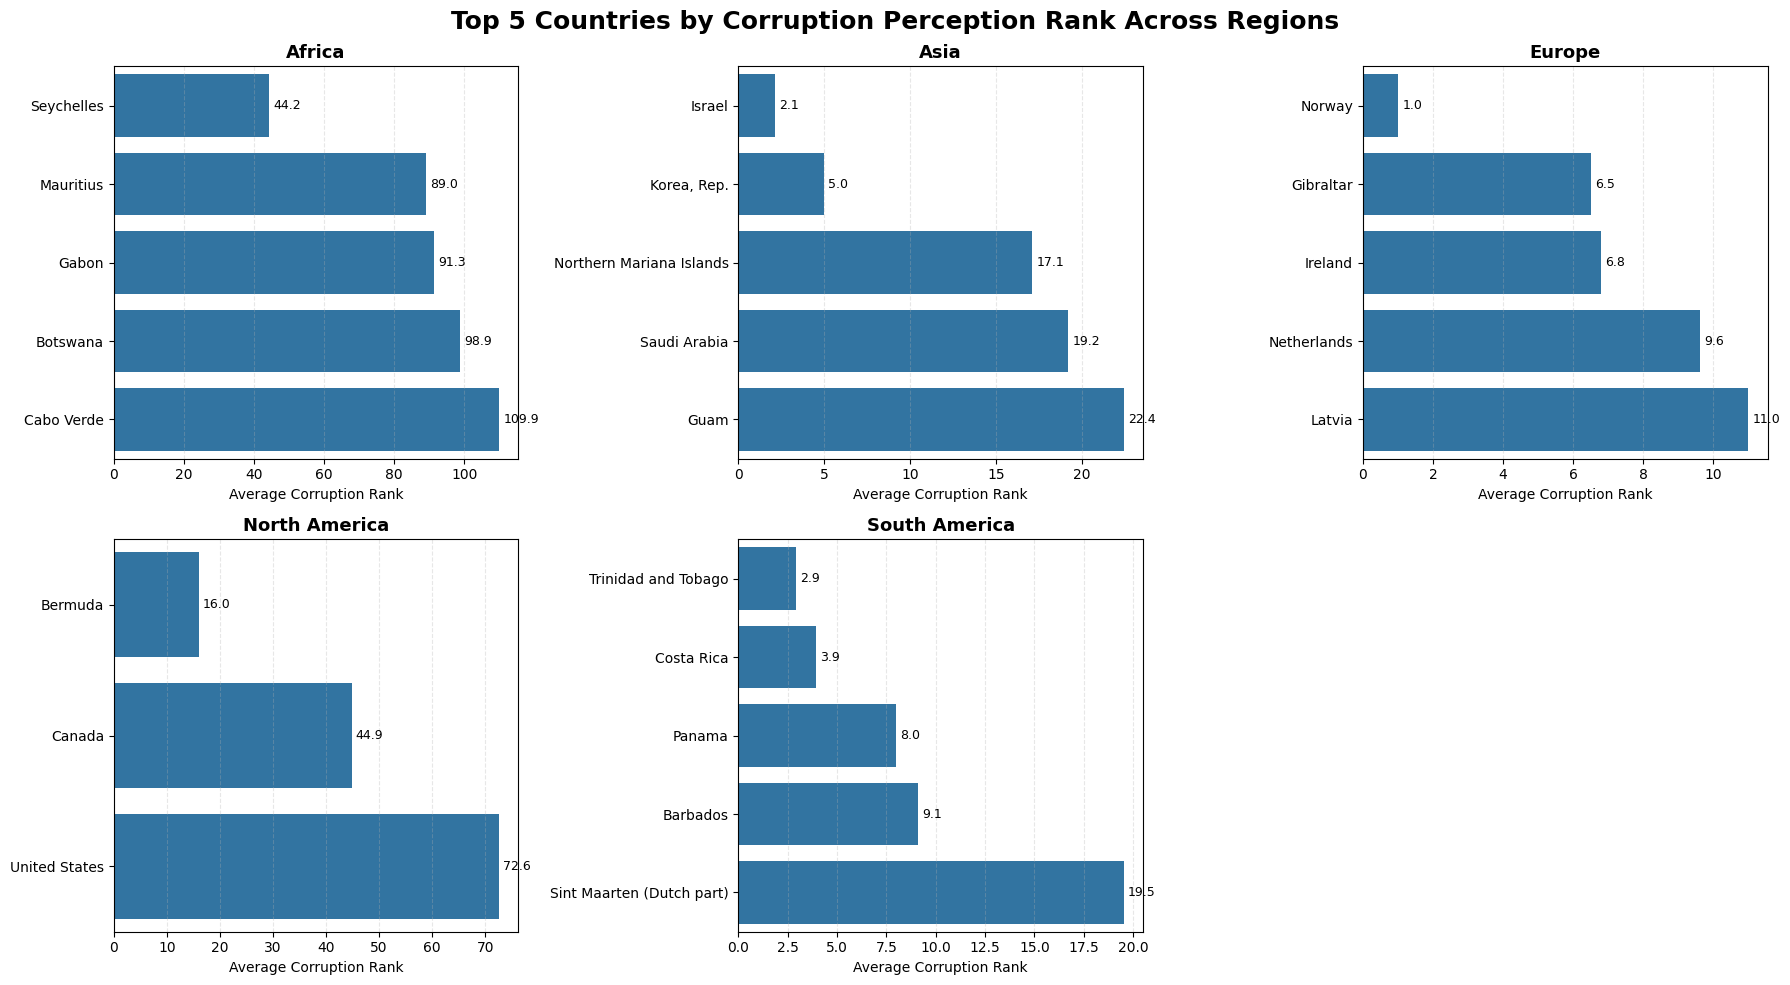

In [35]:
corruption = df.groupby(['region' , 'country']).agg(
    avg_corruprion_rank = ('corruption_perception_rank' , 'mean')
).round(2).reset_index()

top5_country_corruption =  (corruption
      .sort_values(['region', 'avg_corruprion_rank'])
      .groupby('region', group_keys=False)
      .head(5)
      .reset_index(drop=True))
display(top5_country_corruption)

regions = sorted(top5_country_corruption['region'].unique())

n_cols = 3
n_rows = math.ceil(len(regions) / n_cols)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(18, 5 * n_rows)
)

axes = axes.flatten()

for i, region in enumerate(regions):

    temp = (
        top5_country_corruption[top5_country_corruption['region'] == region]
        .sort_values('avg_corruprion_rank')
    )

    ax = axes[i]

    sns.barplot(
        data=temp,
        x='avg_corruprion_rank',
        y='country',
        ax=ax
    )

    # Data labels
    for container in ax.containers:
        ax.bar_label(
            container,
            fmt='%.1f',
            padding=3,
            fontsize=9
        )

    ax.set_title(region, fontsize=13, weight='bold')
    ax.set_xlabel("Average Corruption Rank")
    ax.set_ylabel("")
    ax.grid(axis='x', linestyle='--', alpha=0.3)

    

# Remove unused subplots
for j in range(len(regions), len(axes)):
    fig.delaxes(axes[j])

fig.suptitle(
    "Top 5 Countries by Corruption Perception Rank Across Regions",
    fontsize=18,
    weight='bold'
)

plt.tight_layout()
plt.show()

8 . top 10 country Global rank in Income Equality 

,global_equality
country,
Slovenia,4.78
Belarus,7.33
Czechia,7.52
Norway,10.19
Finland,10.85
Slovak Republic,12.33
Denmark,13.11
Iceland,14.81
Sweden,16.26


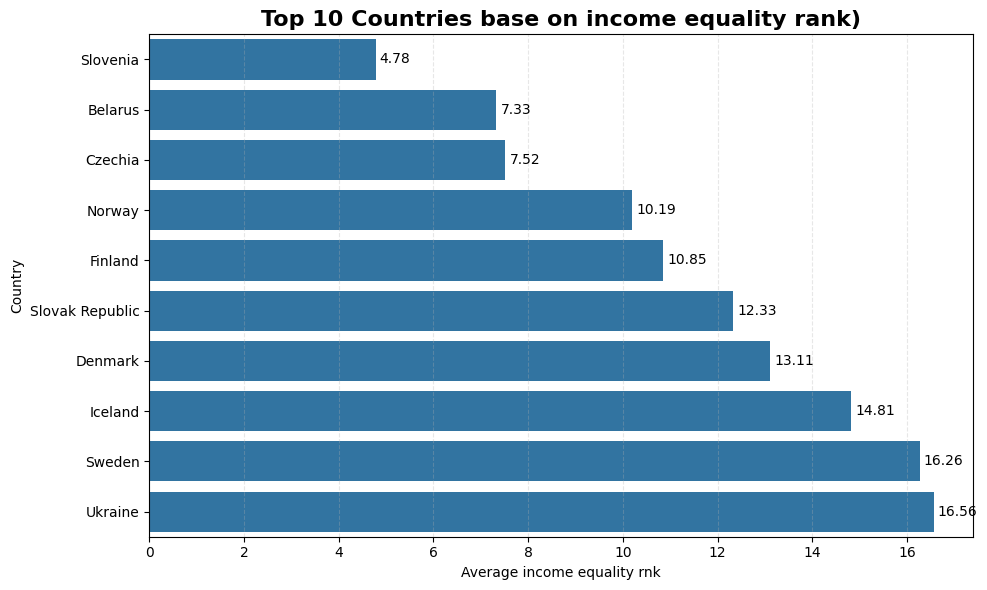

In [5]:
income_equality = df.groupby('country').agg(
    global_equality = ('gini_rank' , 'mean')
).round(2).sort_values(by='global_equality').head(10)
display(income_equality)

plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=income_equality,
    x='global_equality',
    y='country'
)

# Add data labels
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=3, fontsize=10)

plt.title("Top 10 Countries base on income equality rank)",
          fontsize=16, weight='bold')
plt.xlabel("Average income equality rnk")
plt.ylabel("Country")
plt.grid(axis='x', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

9 . top 10 country global rank in press freedom

,press_freedom
country,
Norway,1.00
"Korea, Rep.",2.19
Gibraltar,2.81
Panama,4.78
Virgin Islands (U.S.),4.81
Germany,5.41
San Marino,7.15
Turks and Caicos Islands,7.85
Belgium,9.22


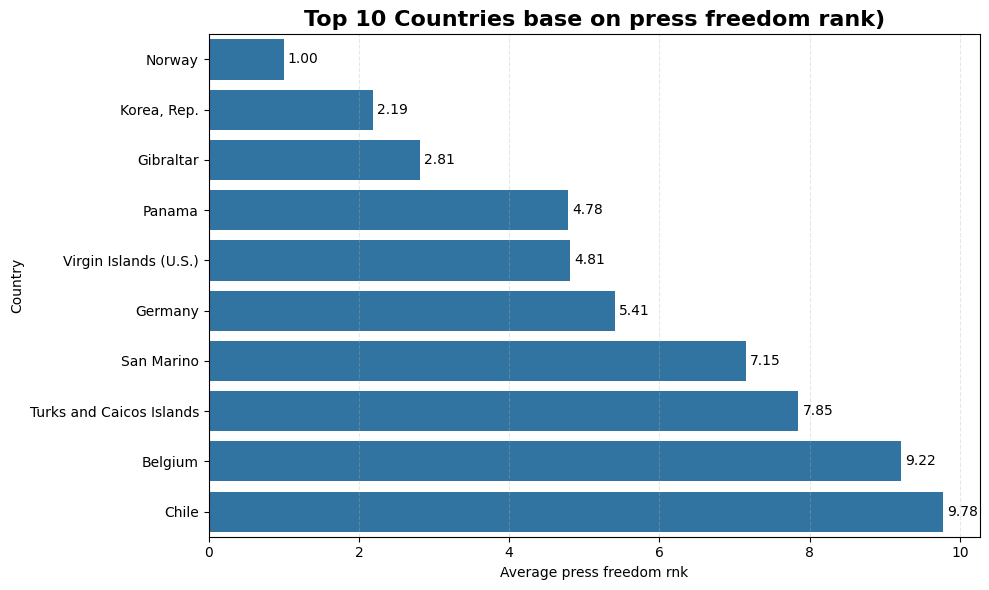

In [9]:
press_freedom = df.groupby('country').agg(
    press_freedom = ('press_freedom_rank' , 'mean')
).sort_values(by='press_freedom').round(2).head(10)
display(press_freedom)

plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=press_freedom,
    x='press_freedom',
    y='country'
)

# Add data labels
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=3, fontsize=10)

plt.title("Top 10 Countries base on press freedom rank)",
          fontsize=16, weight='bold')
plt.xlabel("Average press freedom rnk")
plt.ylabel("Country")
plt.grid(axis='x', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

10 . top 10 country base on peacefull rank of each region

,region,country,avg_peaceful_rnk
37,Africa,Seychelles,10.93
13,Africa,Equatorial Guinea,85.52
17,Africa,Gabon,92.67
2,Africa,Botswana,107.56
29,Africa,Mauritius,120.30
9,Africa,Comoros,129.63
5,Africa,Cabo Verde,130.93
31,Africa,Namibia,132.74
28,Africa,Mauritania,140.56
15,Africa,Eswatini,141.63


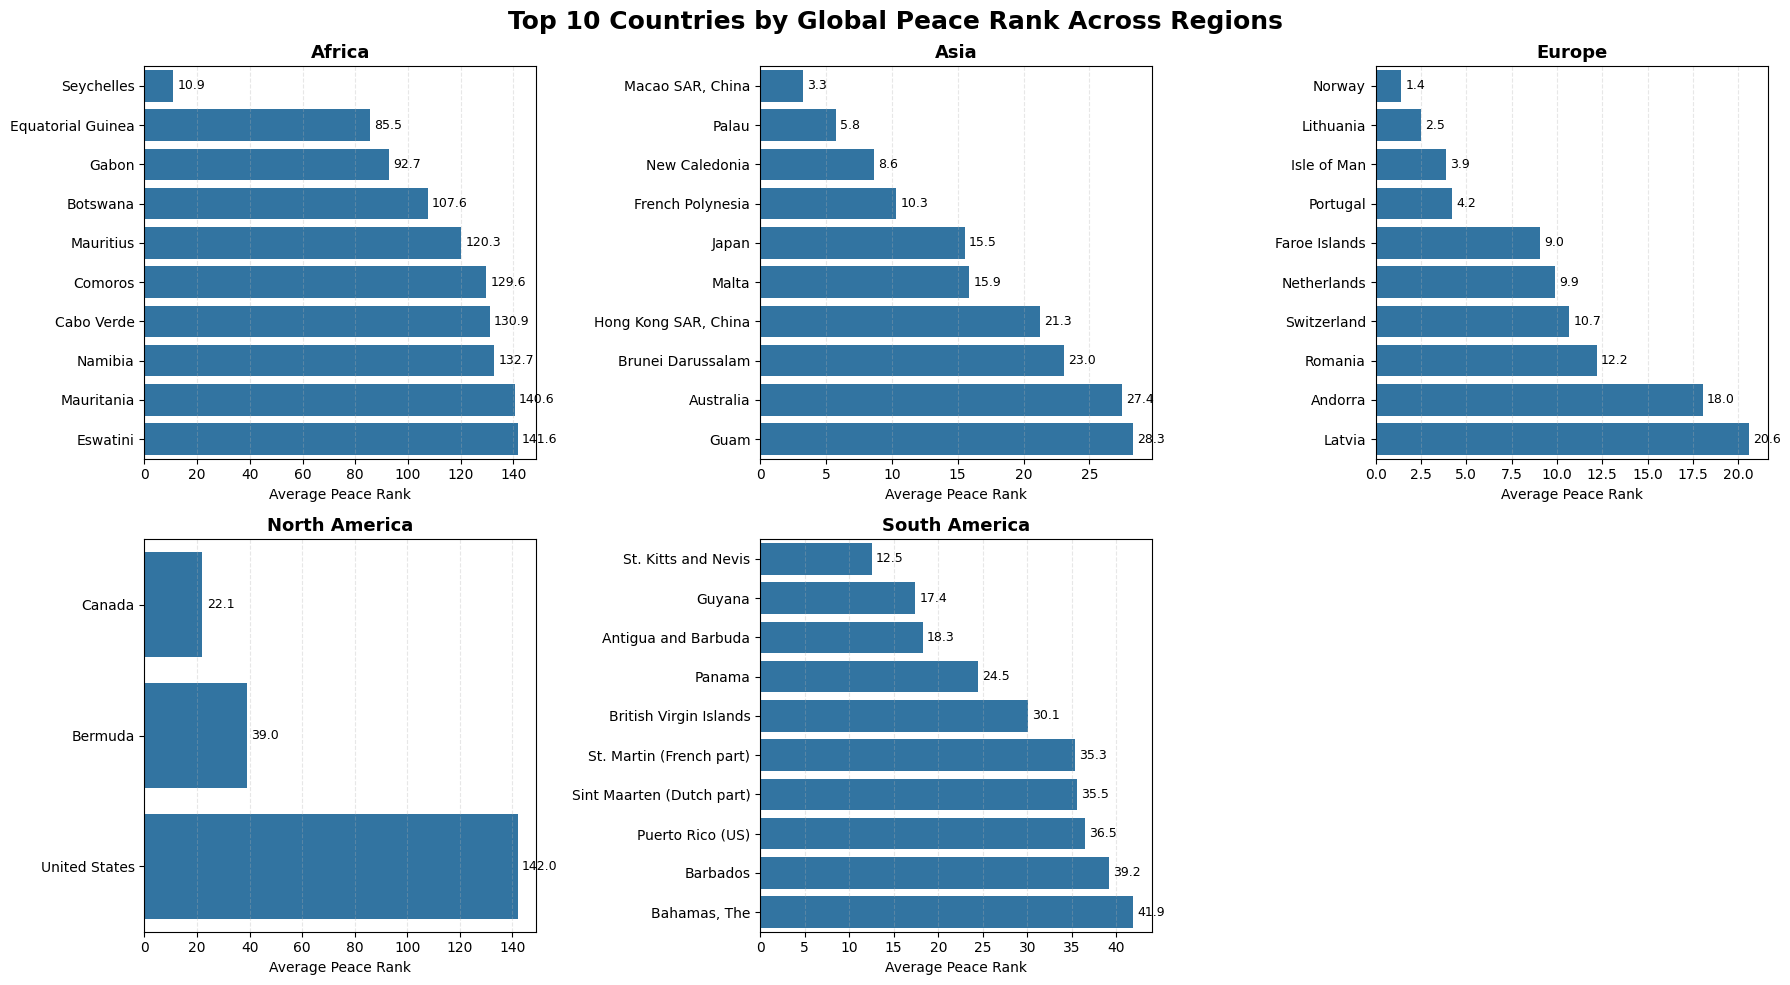

In [23]:
peacefull = df.groupby(['region' , 'country']).agg(
    avg_peaceful_rnk = ('global_peace_rank' , 'mean')
).reset_index()

top10_peacefull_region = (
    peacefull.sort_values(['region','avg_peaceful_rnk']).groupby('region' , group_keys=False).head(10)
).round(2)
display(top10_peacefull_region)
regions = sorted(top10_peacefull_region['region'].unique())

n_cols = 3
n_rows = math.ceil(len(regions) / n_cols)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(18, 5 * n_rows)
)

axes = axes.flatten()

for i, region in enumerate(regions):

    temp = (
        top10_peacefull_region[
            top10_peacefull_region['region'] == region
        ].sort_values('avg_peaceful_rnk')
    )

    ax = axes[i]

    sns.barplot(
        data=temp,
        x='avg_peaceful_rnk',
        y='country',
        ax=ax
    )

    # Data Labels
    for container in ax.containers:
        ax.bar_label(
            container,
            fmt='%.1f',
            padding=3,
            fontsize=9
        )

    ax.set_title(region, fontsize=13, weight='bold')
    ax.set_xlabel("Average Peace Rank")
    ax.set_ylabel("")
    ax.grid(axis='x', linestyle='--', alpha=0.3)

# Remove empty subplot
for j in range(len(regions), len(axes)):
    fig.delaxes(axes[j])

fig.suptitle(
    "Top 10 Countries by Global Peace Rank Across Regions",
    fontsize=18,
    weight='bold'
)

plt.tight_layout()
plt.show()

11 . top 10 country base on environmental performance rank for each region

,region,country,avg_environment_rnk
37,Africa,Seychelles,52.22
17,Africa,Gabon,91.44
5,Africa,Cabo Verde,93.11
13,Africa,Equatorial Guinea,109.85
2,Africa,Botswana,127.00
29,Africa,Mauritius,140.04
40,Africa,South Africa,142.00
46,Africa,Zambia,144.00
1,Africa,Benin,145.04
6,Africa,Cameroon,146.11


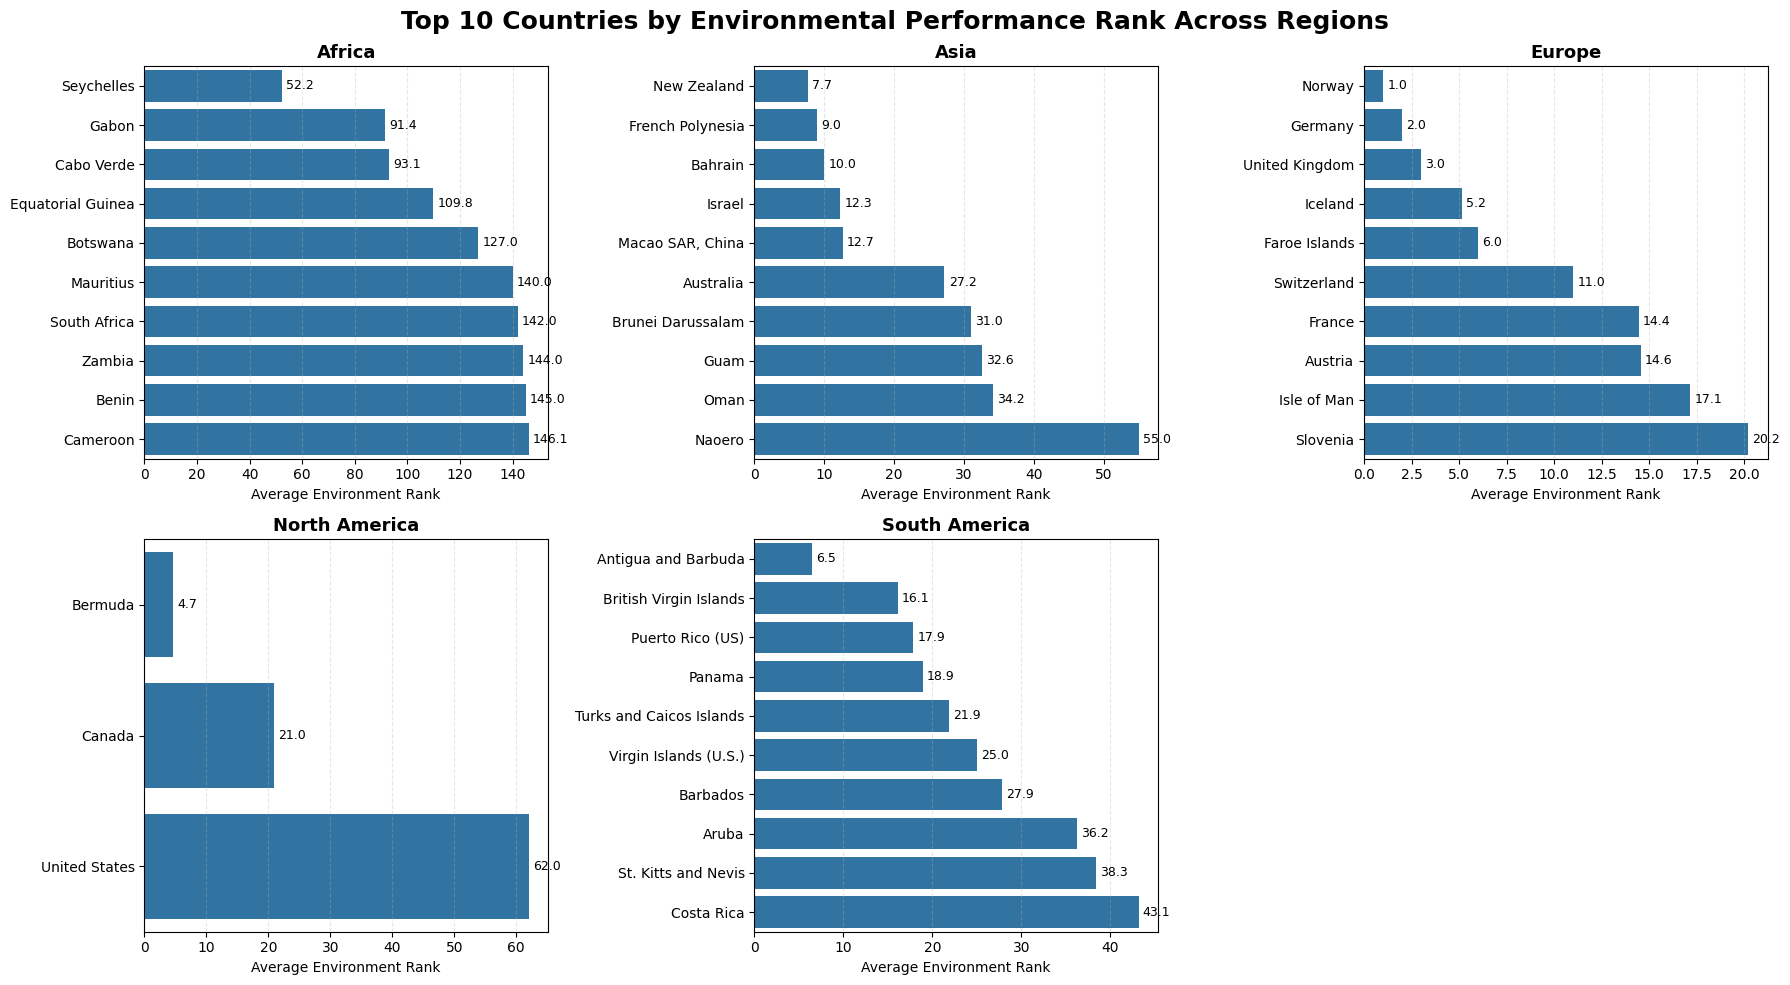

In [20]:
environment_rank = df.groupby(['region' , 'country']).agg(
    avg_environment_rnk = ('environmental_performance_rank' , 'mean')
).reset_index()

top10_environment_region = (
    environment_rank.sort_values(['region','avg_environment_rnk']).groupby('region' , group_keys=False).head(10)
).round(2)
display(top10_environment_region)
regions = sorted(top10_environment_region['region'].unique())

n_cols = 3
n_rows = math.ceil(len(regions) / n_cols)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(18, 5*n_rows)
)

axes = axes.flatten()

for i, region in enumerate(regions):

    temp = (
        top10_environment_region[
            top10_environment_region['region'] == region
        ].sort_values('avg_environment_rnk')
    )

    ax = axes[i]

    sns.barplot(
        data=temp,
        x='avg_environment_rnk',
        y='country',
        ax=ax
    )

    for container in ax.containers:
        ax.bar_label(container, fmt='%.1f', padding=3, fontsize=9)

    ax.set_title(region, fontsize=13, weight='bold')
    ax.set_xlabel("Average Environment Rank")
    ax.set_ylabel("")
    ax.grid(axis='x', linestyle='--', alpha=0.3)

# Remove empty subplot
for j in range(len(regions), len(axes)):
    fig.delaxes(axes[j])

fig.suptitle(
    "Top 10 Countries by Environmental Performance Rank Across Regions",
    fontsize=18,
    weight='bold'
)

plt.tight_layout()
plt.show()

12 . economic tier distriution

In [25]:
economic_tier = df.groupby('economic_tier').agg(
    country_count = ('economic_tier' , 'count')
).sort_values(by='country_count' , ascending=False)
display(economic_tier)

,country_count
economic_tier,
high income,2322
upper middle,1593
lower middle,1269
low,675


In [34]:
panel_check = (
    df.groupby("country")["year"]
      .nunique()
)

panel_check.value_counts()

year
27    217
Name: count, dtype: int64